# Code to generate Figure 6 subplots

In [1]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import NullLocator
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr, pearsonr
from tqdm import trange
import matplotlib.ticker as ticker
import seaborn as sns
import networkx as nx
import matplotlib.colors as mcolors
from itertools import combinations
from statsmodels.stats.multitest import multipletests
from typing import Dict, Optional
from scipy.stats import fisher_exact
from matplotlib.ticker import LogFormatterMathtext
from matplotlib.ticker import AutoMinorLocator

DATA_PATH1 = "../../0-download-inputs/data-files/"
DATA_PATH2 = "../../18-finalize/processed-data/"
DATA_PATH3 = "../../18-Y2H-data/processed-data/"
#ABUNDANCE  = "../../0-download-inputs/data-files/1-s2.0-S240547121730546X-mmc5.csv" # required to join with Y2H dataset
OUT_PATH   = "figures/"
MS_COLOR   = "#DDAA33"
Y2H_COLOR  = "#BB5566"
MS_COLOR_LIGHT = "#EECC66" #color for static (in complex)
MS_COLOR_DARK  = "#997700" #color for dynamic (not in complex)

plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.titlesize": 14,
    "axes.titlepad": 25,
    "font.family": "sans-serif",
    "font.sans-serif": "Arial",
    "figure.facecolor": "white",
    "axes.facecolor": "white"
})

In [2]:
# load the datasets with node centrality information and get nodes in both
nodes = pd.read_pickle(f"{DATA_PATH2}20260210-s288c-ANnnotated-Yeast-Interactome.pkl")

# --- Flip sign of cagiada-dG so downstream code uses the corrected values ---
nodes["cagiada-dG"] = -nodes["cagiada-dG"]

In [3]:
# Filter nodes to remove proteins with low pLDDT and/or are membrane proteins (TM) with/without signal peptide (SP)
filtered_nodes = nodes[
    (nodes['mean_plddt'] >= 70) &
    (~nodes['DeepTMHMM_class'].isin(['SP', 'TM', 'SP+TM']))
].copy()

# Print stats to for nodes
print(f"Original rows: {len(nodes)}")
print(f"Filtered rows: {len(filtered_nodes)}")

Original rows: 3927
Filtered rows: 2466


In [4]:
# determine which nodes are hubs based on percentile cutoff for degree centrality
cut = 0.10
ms_threshold = filtered_nodes['degree_centrality'].quantile(1 - cut)
ms_hubs     = filtered_nodes[filtered_nodes['degree_centrality'] >= ms_threshold]
ms_nothub   = filtered_nodes[filtered_nodes['degree_centrality'] <  ms_threshold]

#y2h_threshold = filtered_nodes['Y2H_degree_centrality'].quantile(1 - cut)
#y2h_hubs      = filtered_nodes[filtered_nodes['Y2H_degree_centrality'] >= y2h_threshold]
#y2h_nothub    = filtered_nodes[filtered_nodes['Y2H_degree_centrality'] <  y2h_threshold]

print(f"Threshold for defining a hub in MS data is {ms_threshold:.5f}; there are {len(ms_hubs)} hubs and {len(ms_nothub)} non hubs")
#print(f"Threshold for defining a hub in Y2H data is {y2h_threshold:.5f}; there are {len(y2h_hubs)} hubs and {len(y2h_nothub)} non hubs")

Threshold for defining a hub in MS data is 0.01503; there are 252 hubs and 2214 non hubs


In [5]:
# Load chaperone data
# Parse the interacting_chaperones column if it's a string representation of a list
nodes['interacting_chaperones'] = nodes['interacting_chaperones'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Compute number of chaperone interactions
nodes['num_chaperone_interactions'] = nodes['interacting_chaperones'].apply(len)

# Compute total degree for each node from full MS interactome
f_ms_edges = pd.read_csv(f"{DATA_PATH1}The_Yeast_Interactome_edges.csv")
f_ms_edges = f_ms_edges.rename(columns={"source": "node1", "target": "node2"})

G = nx.from_pandas_edgelist(f_ms_edges, "node1", "node2", create_using=nx.Graph())
degree_dict = dict(G.degree())

degree_df = pd.DataFrame({
    "node": list(degree_dict.keys()),
    "total_degree": list(degree_dict.values())
})

# Merge degree and compute chaperone fraction
#Now every protein has: number of chaperone contacts, total degree, fraction of interactions involving chaperones
merged_df = nodes.merge(degree_df, left_on="node", right_on="node", how="inner")
merged_df = merged_df[merged_df['total_degree'] > 0] # avoid divide-by-zero
merged_df['chaperone_fraction'] = (100 * merged_df['num_chaperone_interactions'] / merged_df['total_degree'])

# Integrate classifications
class_df = filtered_nodes[['node', 'in_complex']].copy()

# Hub assignment for degree centrality
class_df['is_hub'] = class_df['node'].isin(ms_hubs['node'])

# Define hub type:
# static  = hub & in_complex == True
# dynamic = hub & in_complex == False
# nonhub  = everything else
def assign_hub_type(row):
    if row['is_hub']:
        return "static" if row['in_complex'] else "dynamic"
    else:
        return "nonhub"

class_df['hub_type'] = class_df.apply(assign_hub_type, axis=1)

# Merge classification into merged_df
final_df = merged_df.merge(
    class_df[['node', 'is_hub', 'hub_type']],
    on='node',
    how='left'
)

# Define simple chaperone boolean
final_df["has_chaperone"] = final_df["num_chaperone_interactions"] > 0

#print(final_df.head())

## Figure 6A

* Create histograms to visualise distribution of chaperone fraction (%) for hubs and non-hubs across AE-MS dataset

In [6]:
# Extract chaperone fraction for hubs vs non-hubs
hub_frac = final_df[final_df["is_hub"] == True]["chaperone_fraction"].replace([np.inf, -np.inf], np.nan).dropna() / 100  # Directly to fraction
nonhub_frac = final_df[final_df["is_hub"] == False]["chaperone_fraction"].replace([np.inf, -np.inf], np.nan).dropna() / 100

# Extract NON-ZERO chaperone fraction for hubs vs non-hubs
hub_nz    = hub_frac[hub_frac > 0]
nonhub_nz = nonhub_frac[nonhub_frac > 0]

# Sanity checks
print(f"Hubs: {len(hub_nz)}/{len(hub_frac)} non-zero ({100 * len(hub_nz) / len(hub_frac):.2f}% have non-zero chaperone fraction)")
print(f"Non-hubs: {len(nonhub_nz)}/{len(nonhub_frac)} non-zero ({100 * len(nonhub_nz) / len(nonhub_frac):.2f}% have non-zero chaperone fraction)")

# Proportion with >=1 chaperone (not median!)
hub_prop_with_chap = (final_df[final_df["is_hub"] == True]["num_chaperone_interactions"] > 0).mean()
nonhub_prop_with_chap = (final_df[final_df["is_hub"] == False]["num_chaperone_interactions"] > 0).mean()
print(f"Hub proportion with >=1 chaperone: {hub_prop_with_chap:.2f}")
print(f"Non-hub proportion with >=1 chaperone: {nonhub_prop_with_chap:.2f}")

# MWU on full (including zeros, two-sided greater)
print("=== MWU on Full Chaperone Fractions (Hubs vs Non-Hubs, two-sided greater) ===")
print(f"n(hubs) = {len(hub_frac)}, n(nonhubs) = {len(nonhub_frac)}")
print(f"median(hubs) = {np.median(hub_frac):.2f}, median(nonhubs) = {np.median(nonhub_frac):.2f}")
ms_u, ms_p = mannwhitneyu(hub_frac, nonhub_frac, alternative="two-sided")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

# MWU on full (including zeros, one-sided greater)
print("=== MWU on Full Chaperone Fractions (Hubs vs Non-Hubs, one-sided greater) ===")
print(f"n(hubs) = {len(hub_frac)}, n(nonhubs) = {len(nonhub_frac)}")
print(f"median(hubs) = {np.median(hub_frac):.2f}, median(nonhubs) = {np.median(nonhub_frac):.2f}")
ms_u, ms_p = mannwhitneyu(hub_frac, nonhub_frac, alternative="greater")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")


# MWU on non-zero (two-sided)
#print("=== MWU on Non-Zero Chaperone Fractions (Hubs vs Non-Hubs, two-sided) ===")
#print(f"n(hubs) = {len(hub_nz)}, n(nonhubs) = {len(nonhub_nz)}")
#print(f"median(hubs) = {np.median(hub_nz):.2f}, median(nonhubs) = {np.median(nonhub_nz):.2f}")
#ms_u, ms_p = mannwhitneyu(hub_nz, nonhub_nz, alternative="two-sided")
#print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

#print("=== MWU on Non-Zero Chaperone Fractions (Hubs vs Non-Hubs, one-sided) ===")
#print(f"n(hubs) = {len(hub_nz)}, n(nonhubs) = {len(nonhub_nz)}")
#print(f"median(hubs) = {np.median(hub_nz):.2f}, median(nonhubs) = {np.median(nonhub_nz):.2f}")
#ms_u, ms_p = mannwhitneyu(hub_nz, nonhub_nz, alternative="greater")
#print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

Hubs: 82/252 non-zero (32.54% have non-zero chaperone fraction)
Non-hubs: 323/2214 non-zero (14.59% have non-zero chaperone fraction)
Hub proportion with >=1 chaperone: 0.33
Non-hub proportion with >=1 chaperone: 0.15
=== MWU on Full Chaperone Fractions (Hubs vs Non-Hubs, two-sided greater) ===
n(hubs) = 252, n(nonhubs) = 2214
median(hubs) = 0.00, median(nonhubs) = 0.00
U = 317619.50, p = 2.212e-08
=== MWU on Full Chaperone Fractions (Hubs vs Non-Hubs, one-sided greater) ===
n(hubs) = 252, n(nonhubs) = 2214
median(hubs) = 0.00, median(nonhubs) = 0.00
U = 317619.50, p = 1.106e-08


In [7]:
df = final_df.copy()
df = df.replace([np.inf, -np.inf], np.nan)

# Binary outcome (same for both analyses)
df["has_chap"] = (df["num_chaperone_interactions"].fillna(0) > 0)

def bootstrap_ct_fast(
    df: pd.DataFrame,
    col1: str,
    col2: str,
    n: Optional[int] = None,
    B: int = 1_000_000,
    alpha: float = 0.05,
    seed: Optional[int] = 0,
    correction: float = 0.0,   
) -> Dict[str, object]:
    
    sub = df[[col1, col2]].dropna().astype(bool)
    N = len(sub)
    if N == 0:
        raise ValueError("No rows after dropping NA.")
    if n is None:
        n = N

    # observed counts
    a = int(((sub[col1]) & (sub[col2])).sum())              # True, True
    b = int(((sub[col1]) & (~sub[col2])).sum())             # True, False
    c = int(((~sub[col1]) & (sub[col2])).sum())             # False, True
    d = int(((~sub[col1]) & (~sub[col2])).sum())            # False, False

    table = np.array([[a, b],
                      [c, d]], dtype=int)

    # "Observed" odds ratio from Fisher's exact test (fine to do once)
    odds_ratio_fisher, p_value = fisher_exact(table, alternative="two-sided")

    # Also compute the standard cross-product OR (used for bootstrap below)
    or_obs = ((a + correction) * (d + correction)) / ((b + correction) * (c + correction))
    odds1_obs = (a + correction) / (b + correction)
    odds2_obs = (c + correction) / (d + correction)

    # Multinomial probabilities from empirical distribution
    p = np.array([a, b, c, d], dtype=float) / N

    rng = np.random.default_rng(seed)

    # Draw all bootstrap tables at once (very fast)
    boot = rng.multinomial(n, p, size=B).astype(np.int32)
    boot_a, boot_b, boot_c, boot_d = boot.T  # each is (B,)

    # Vectorized odds / OR with correction
    boot_odds1 = (boot_a + correction) / (boot_b + correction)
    boot_odds2 = (boot_c + correction) / (boot_d + correction)
    boot_or    = ((boot_a + correction) * (boot_d + correction)) / ((boot_b + correction) * (boot_c + correction))

    # percentile CIs
    lo_q = alpha / 2
    hi_q = 1 - alpha / 2

    def ci(x: np.ndarray):
        return (float(np.quantile(x, lo_q)), float(np.quantile(x, hi_q)))

    a_ci = ci(boot_a); b_ci = ci(boot_b); c_ci = ci(boot_c); d_ci = ci(boot_d)
    odds1_ci = ci(boot_odds1); odds2_ci = ci(boot_odds2); or_ci = ci(boot_or)

    return {
        "a": a, "b": b, "c": c, "d": d,
        "a_lower": a_ci[0], "a_upper": a_ci[1],
        "b_lower": b_ci[0], "b_upper": b_ci[1],
        "c_lower": c_ci[0], "c_upper": c_ci[1],
        "d_lower": d_ci[0], "d_upper": d_ci[1],

        # Fisher OR / p-value for the observed table 
        "odds_ratio_fisher": float(odds_ratio_fisher),
        "p_value_fisher": float(p_value),

        # bootstrap distribution information for the cross-product OR and per-row odds
        "odds_ratio": float(or_obs), "odds_ratio_lower": or_ci[0], "odds_ratio_upper": or_ci[1],
        "row1_odds": float(odds1_obs), "row1_odds_lower": odds1_ci[0], "row1_odds_upper": odds1_ci[1],
        "row2_odds": float(odds2_obs), "row2_odds_lower": odds2_ci[0], "row2_odds_upper": odds2_ci[1],

    }
    
# Create boolean hub indicator
df["is_hub_bool"] = df["is_hub"].fillna(False).astype(bool)

# Run bootstrap
results_hub = bootstrap_ct_fast(
    df=df,
    col1="is_hub_bool",           # row grouping: hub = True
    col2="has_chap",              # column: has chaperone interaction
    n=None,                       # = full sample size
    B=1_000_000,
    alpha=0.05,
    seed=42,
    correction=0.5                # common choice; set to 0.0 if you want uncorrected
)

print("\n" + "="*70)
print("Hub vs Non-hub: Chaperone Interaction")
print("="*70)

print("Contingency table:")
print("                Has Chap     No Chap")
print(f"Hub             {results_hub['a']:>9d}      {results_hub['b']:>9d}     ← hub & has chap")
print(f"Non-hub         {results_hub['c']:>9d}      {results_hub['d']:>9d}     ← non-hub & has chap")
print()

print("=== Hub vs Non-hub: any chaperone interaction (>=1) ===")
print(f"Hub:     {results_hub['a']}/{results_hub['a'] + results_hub['b']} have >=1 interaction "
      f"({100 * results_hub['a'] / (results_hub['a'] + results_hub['b']):.2f}%)")
print(f"Non-hub: {results_hub['c']}/{results_hub['c'] + results_hub['d']} have >=1 interaction "
      f"({100 * results_hub['c'] / (results_hub['c'] + results_hub['d']):.2f}%)")
print()

print("Fisher's exact test (observed table):")
print(f"  Odds ratio (two-sided)              = {results_hub['odds_ratio_fisher']:.3f}")
print(f"  two-sided p-value                   = {results_hub['p_value_fisher']:.4g}")

# Compute one-sided p-value (hubs > non-hubs)
or_greater, p_greater = fisher_exact(
    [[results_hub['a'], results_hub['b']],
     [results_hub['c'], results_hub['d']]],
    alternative="greater"
)

print(f"  one-sided OR (hubs > non-hubs)      = {or_greater:.3f}")
print(f"  one-sided p-value (hubs > non-hubs) = {p_greater:.4g}")

# Add significance stars
stars = "***" if p_greater < 0.001 else "**" if p_greater < 0.01 else "*" if p_greater < 0.05 else "ns"
print(f"  Significance (one-sided, hubs > non-hubs): {stars}")
print()

print("Bootstrap cross-product odds ratio (with correction):")
print(f"  Odds ratio (hub / non-hub)          = {results_hub['odds_ratio']:.3f}")
print(f"    95% percentile CI                 = {results_hub['odds_ratio_lower']:.3f} – {results_hub['odds_ratio_upper']:.3f}")
print()

print("Bootstrap conditional odds:")
print(f"  Odds(has chap | hub)                = {results_hub['row1_odds']:.3f}    95% CI: {results_hub['row1_odds_lower']:.3f} – {results_hub['row1_odds_upper']:.3f}")
print(f"  Odds(has chap | non-hub)            = {results_hub['row2_odds']:.3f}    95% CI: {results_hub['row2_odds_lower']:.3f} – {results_hub['row2_odds_upper']:.3f}")

/tmp/ipykernel_2050/2775134684.py:85: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["is_hub_bool"] = df["is_hub"].fillna(False).astype(bool)



Hub vs Non-hub: Chaperone Interaction
Contingency table:
                Has Chap     No Chap
Hub                    82            170     ← hub & has chap
Non-hub               484           3191     ← non-hub & has chap

=== Hub vs Non-hub: any chaperone interaction (>=1) ===
Hub:     82/252 have >=1 interaction (32.54%)
Non-hub: 484/3675 have >=1 interaction (13.17%)

Fisher's exact test (observed table):
  Odds ratio (two-sided)              = 3.180
  two-sided p-value                   = 3.17e-14
  one-sided OR (hubs > non-hubs)      = 3.180
  one-sided p-value (hubs > non-hubs) = 2.926e-14
  Significance (one-sided, hubs > non-hubs): ***

Bootstrap cross-product odds ratio (with correction):
  Odds ratio (hub / non-hub)          = 3.187
    95% percentile CI                 = 2.387 – 4.190

Bootstrap conditional odds:
  Odds(has chap | hub)                = 0.484    95% CI: 0.368 – 0.625
  Odds(has chap | non-hub)            = 0.152    95% CI: 0.138 – 0.167


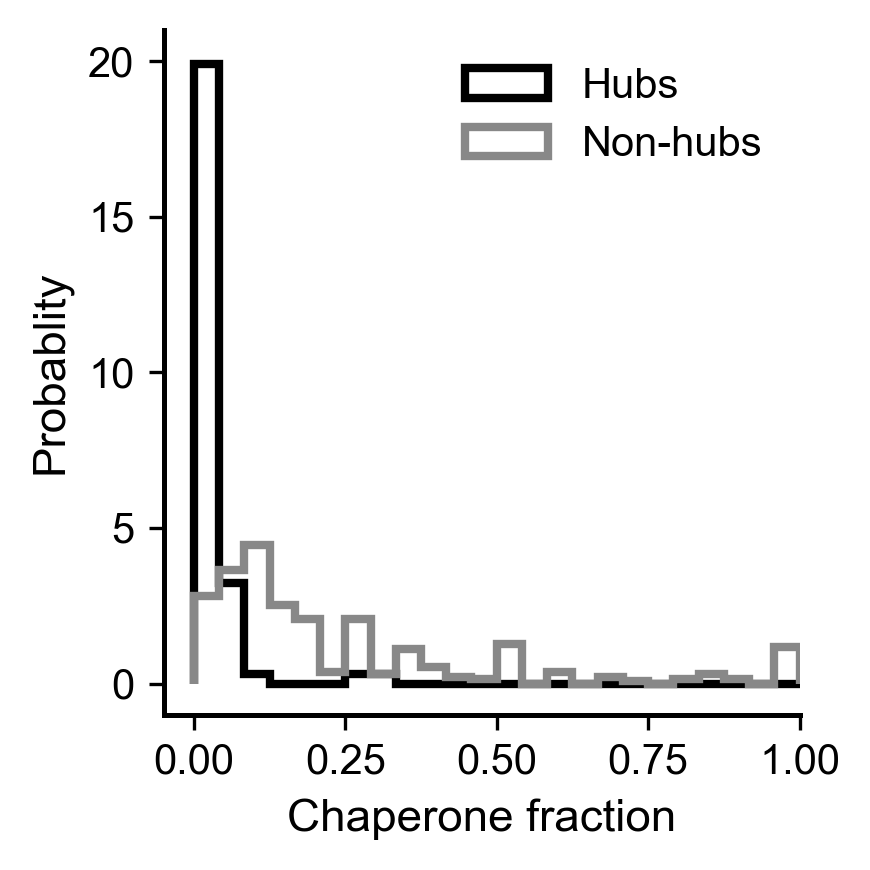

In [8]:
fig, ax = plt.subplots(figsize=(3, 3))

bins = np.linspace(
    0,
    max(hub_nz.max(), nonhub_nz.max()),
    25
)

ax.hist(
    hub_nz,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=2,
    linestyle="-",
    color='black',
    label="Hubs"
)

ax.hist(
    nonhub_nz,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=2,
    linestyle="-",
    color='#888888',
    label="Non-hubs"
)

ax.set_xlabel("Chaperone fraction", fontsize=11)
ax.set_ylabel("Probablity", fontsize=11)
ax.set_xlim(-0.05, 1)
ax.set_ylim(-1, 21)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)
ax.legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig("6-A.svg")
plt.show()


## Figure 6B
* Create histograms to visualise distribution of chaperone fraction (%) for hubs and non-hubs across AE-MS dataset

In [9]:
# Filter hubs only
hubs_df = final_df[final_df["hub_type"].isin(["static", "dynamic"])].copy()

# Clean values
static_frac = hubs_df[hubs_df["hub_type"] == "static"]["chaperone_fraction"]\
    .replace([np.inf, -np.inf], np.nan).dropna() / 100
dynamic_frac = hubs_df[hubs_df["hub_type"] == "dynamic"]["chaperone_fraction"]\
    .replace([np.inf, -np.inf], np.nan).dropna() / 100

static_nz = static_frac[static_frac > 0]
dynamic_nz = dynamic_frac[dynamic_frac > 0]

# Group sizes
n_static = len(static_frac)
n_dynamic = len(dynamic_frac)
print(f"Static hubs: n = {n_static}")
print(f"Dynamic hubs: n = {n_dynamic}")

# Non-zero counts & %
print(f"Static hubs non-zero: {len(static_nz)} / {n_static}  ({100 * len(static_nz)/n_static:.2f}%)")
print(f"Dynamic hubs non-zero: {len(dynamic_nz)} / {n_dynamic}  ({100 * len(dynamic_nz)/n_dynamic:.2f}%)")

# Proportions with >=1 chaperone interaction (this is your main interest)
prop_static = (hubs_df[hubs_df["hub_type"] == "static"]["num_chaperone_interactions"] > 0).mean()
prop_dynamic = (hubs_df[hubs_df["hub_type"] == "dynamic"]["num_chaperone_interactions"] > 0).mean()
print(f"\nProportion with ≥1 chaperone interaction:")
print(f"  Static hubs: {prop_static:.4f}  ({prop_static*100:.2f}%)")
print(f"  Dynamic hubs: {prop_dynamic:.4f}  ({prop_dynamic*100:.2f}%)")

# ─── MWU on FULL fractions (including zeros) ───
print("\n=== MWU on full chaperone fractions (including zeros) ===")
u_full, p_full_two = mannwhitneyu(static_frac, dynamic_frac, alternative="two-sided")
u_full_greater, p_full_greater = mannwhitneyu(static_frac, dynamic_frac, alternative="less")  # static < dynamic?
print(f"Two-sided:   U = {u_full:.1f}, p = {p_full_two:.4g}")
print(f"One-sided (static < dynamic): p = {p_full_greater:.4g}")
print(f"medians: static = {np.median(static_frac):.4f}, dynamic = {np.median(dynamic_frac):.4f}")

# ─── MWU on NON-ZERO only ───
#print("\n=== MWU on non-zero chaperone fractions only ===")
#if len(static_nz) > 5 and len(dynamic_nz) > 5:  # rough check for enough data
#    u_nz, p_nz_two = mannwhitneyu(static_nz, dynamic_nz, alternative="two-sided")
#    u_nz_greater, p_nz_greater = mannwhitneyu(static_nz, dynamic_nz, alternative="less")
#    print(f"Two-sided:   U = {u_nz:.1f}, p = {p_nz_two:.4g}")
#    print(f"One-sided (static < dynamic): p = {p_nz_greater:.4g}")
#    print(f"medians: static = {np.median(static_nz):.4f}, dynamic = {np.median(dynamic_nz):.4f}")
#else:
#    print("Not enough non-zero values in one or both groups for reliable MWU.")

Static hubs: n = 134
Dynamic hubs: n = 118
Static hubs non-zero: 26 / 134  (19.40%)
Dynamic hubs non-zero: 56 / 118  (47.46%)

Proportion with ≥1 chaperone interaction:
  Static hubs: 0.1940  (19.40%)
  Dynamic hubs: 0.4746  (47.46%)

=== MWU on full chaperone fractions (including zeros) ===
Two-sided:   U = 5852.0, p = 1.934e-05
One-sided (static < dynamic): p = 9.671e-06
medians: static = 0.0000, dynamic = 0.0000


In [10]:
# Subset to hubs only
df_hubs = df[df["hub_type"].isin(["static", "dynamic"])].copy()

# Create boolean: dynamic = True, static = False
df_hubs["is_dynamic_bool"] = (df_hubs["hub_type"] == "dynamic")

# Run bootstrap — dynamic on "row 1" to match your hypothesis
results_dyn_stat = bootstrap_ct_fast(
    df=df_hubs,
    col1="is_dynamic_bool",       # row grouping: dynamic = True
    col2="has_chap",
    n=None,
    B=1_000_000,
    alpha=0.05,
    seed=42,
    correction=0.5
)

# ... (your bootstrap call remains unchanged)

print("\n" + "="*70)
print("Dynamic vs Static Hubs: Chaperone Interaction")
print("="*70)

print("Contingency table:")
print("                Has Chap     No Chap")
print(f"Dynamic hubs    {results_dyn_stat['a']:>9d}      {results_dyn_stat['b']:>9d}     ← dynamic & has chap")
print(f"Static hubs     {results_dyn_stat['c']:>9d}      {results_dyn_stat['d']:>9d}     ← static & has chap")
print()

print("=== Dynamic vs Static hubs: any chaperone interaction (>=1) ===")
print(f"Dynamic hubs: {results_dyn_stat['a']}/{results_dyn_stat['a'] + results_dyn_stat['b']} "
      f"have >=1 interaction ({100 * results_dyn_stat['a'] / (results_dyn_stat['a'] + results_dyn_stat['b']):.2f}%)")
print(f"Static hubs:  {results_dyn_stat['c']}/{results_dyn_stat['c'] + results_dyn_stat['d']} "
      f"have >=1 interaction ({100 * results_dyn_stat['c'] / (results_dyn_stat['c'] + results_dyn_stat['d']):.2f}%)")
print()

print("Fisher's exact test (observed table):")
print(f"  Odds ratio (two-sided)              = {results_dyn_stat['odds_ratio_fisher']:.3f}")
print(f"  two-sided p-value                   = {results_dyn_stat['p_value_fisher']:.4g}")

# One-sided calculation and print
or_greater, p_greater = fisher_exact(
    [[results_dyn_stat['a'], results_dyn_stat['b']],
     [results_dyn_stat['c'], results_dyn_stat['d']]],
    alternative="greater"
)
print(f"  one-sided OR (dynamic > static)     = {or_greater:.3f}")
print(f"  one-sided p-value (dynamic > static) = {p_greater:.4g}")

stars = "***" if p_greater < 0.001 else "**" if p_greater < 0.01 else "*" if p_greater < 0.05 else "ns"
print(f"  Significance (one-sided, dynamic > static): {stars}")
print()

print("Bootstrap cross-product odds ratio (with correction):")
print(f"  Odds ratio (dynamic / static)       = {results_dyn_stat['odds_ratio']:.3f}")
print(f"    95% percentile CI                 = {results_dyn_stat['odds_ratio_lower']:.3f} – {results_dyn_stat['odds_ratio_upper']:.3f}")
print()


Dynamic vs Static Hubs: Chaperone Interaction
Contingency table:
                Has Chap     No Chap
Dynamic hubs           56             62     ← dynamic & has chap
Static hubs            26            108     ← static & has chap

=== Dynamic vs Static hubs: any chaperone interaction (>=1) ===
Dynamic hubs: 56/118 have >=1 interaction (47.46%)
Static hubs:  26/134 have >=1 interaction (19.40%)

Fisher's exact test (observed table):
  Odds ratio (two-sided)              = 3.752
  two-sided p-value                   = 2.224e-06
  one-sided OR (dynamic > static)     = 3.752
  one-sided p-value (dynamic > static) = 1.764e-06
  Significance (one-sided, dynamic > static): ***

Bootstrap cross-product odds ratio (with correction):
  Odds ratio (dynamic / static)       = 3.701
    95% percentile CI                 = 2.168 – 6.705



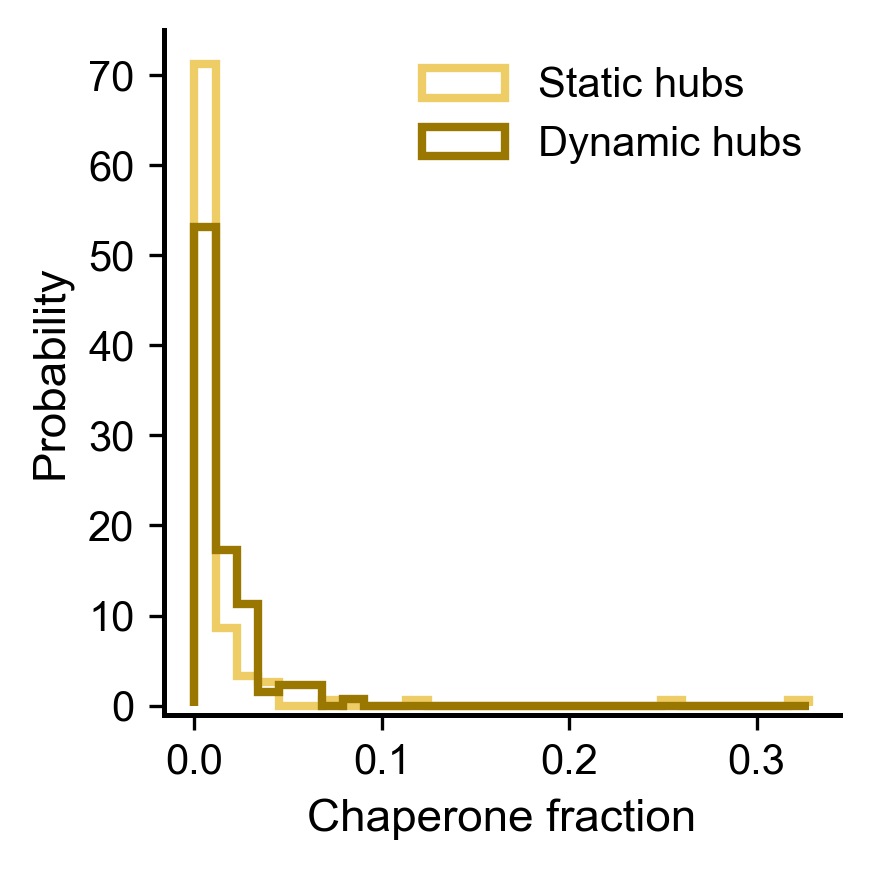

In [12]:
fig, ax = plt.subplots(figsize=(3, 3))

bins = np.linspace(
    0,
    max(static_frac.max(), dynamic_frac.max()),
    30
)

ax.hist(
    static_frac,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=2,
    linestyle="-",
    color=MS_COLOR_LIGHT,
    label="Static hubs"
)

ax.hist(
    dynamic_frac,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=2,
    linestyle="-",
    color=MS_COLOR_DARK,
    label="Dynamic hubs"
)

ax.set_xlabel("Chaperone fraction", fontsize=11)
ax.set_ylabel("Probability", fontsize=11)
#ax.set_xlim(-0.1, 0.35)
ax.set_ylim(-1, 75)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)
ax.legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig("6-B.svg")
plt.show()

## EXTRA SUPP

* Boxplot of Turnover kinetics (t1/2 min) of chaperone associated hubs and chaperone independent hubs

In [13]:
def bootstrap_ci_median(values, B=1_000_000, ci=95, random_state=27):
    """
    Nonparametric bootstrap CI for the median.

    values: 1D array-like
    B: number of bootstrap resamples
    ci: confidence level (e.g., 95)
    """
    vals = np.asarray(values)
    vals = vals[np.isfinite(vals)]
    n = len(vals)
    if n == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(random_state)
    medians = np.empty(B, dtype=float)

    # Loop-based bootstrap to avoid large memory allocations
    for b in trange(B, desc="Bootstrapping medians"):
        sample = rng.choice(vals, size=n, replace=True)
        medians[b] = np.median(sample)

    median_hat = np.median(vals)
    alpha = 100 - ci
    lower = np.percentile(medians, alpha / 2)
    upper = np.percentile(medians, 100 - alpha / 2)
    return median_hat, lower, upper
    
# Create a boolean for chaperone interaction
final_df["has_chaperone"] = final_df["num_chaperone_interactions"] > 0

# HUBS ONLY (degree-based MS hubs already computed)
hub_df = final_df[final_df["is_hub"] == True].copy()

halflife_hub_chap     = hub_df[hub_df["has_chaperone"] == True]["Villen_halflife_min"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()
halflife_hub_nochap   = hub_df[hub_df["has_chaperone"] == False]["Villen_halflife_min"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

# Groups: (label, data, color)
groups = [
    ("Hub + Chaperone", halflife_hub_chap, MS_COLOR_LIGHT),
    ("Hub + No Chaperone", halflife_hub_nochap, MS_COLOR_DARK),
]

# 2. Compute bootstrapped medians + CIs
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:12<00:00, 78486.91it/s]


Hub + Chaperone: median=91.80, 95% CI=(91.20, 92.40), n=67)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 71876.19it/s]

Hub + No Chaperone: median=88.80, 95% CI=(77.40, 91.20), n=157)


In [14]:
# MWU test — Hub+Chap vs Hub+NoChap
ms_u, ms_p = mannwhitneyu(halflife_hub_chap, halflife_hub_nochap, alternative="two-sided")

print("=== Mann–Whitney U tests on Villen_halflife_min ===")

print("\nMS Hub - Chaperone  associated vs MS Hub - Chaperone  independent")
print(f"n(chap) = {len(halflife_hub_chap)}, n(nochap) = {len(halflife_hub_nochap)}")
print(f"median(chap) = {np.median(halflife_hub_chap):.2f}, median(nochap) = {np.median(halflife_hub_nochap):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")


# ONE-SIDED MWU test — Hub+Chap vs Hub+NoChap
ms_u, ms_p = mannwhitneyu(halflife_hub_chap, halflife_hub_nochap, alternative="greater")

print("=== Mann–Whitney U tests on Villen_halflife_min ===")

print("\nMS Hub - Chaperone  associated vs MS Hub - Chaperone  independent")
print(f"n(chap) = {len(halflife_hub_chap)}, n(nochap) = {len(halflife_hub_nochap)}")
print(f"median(chap) = {np.median(halflife_hub_chap):.2f}, median(nochap) = {np.median(halflife_hub_nochap):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

=== Mann–Whitney U tests on Villen_halflife_min ===

MS Hub - Chaperone  associated vs MS Hub - Chaperone  independent
n(chap) = 67, n(nochap) = 157
median(chap) = 91.80, median(nochap) = 88.80
U = 6196.50, p = 0.03492
=== Mann–Whitney U tests on Villen_halflife_min ===

MS Hub - Chaperone  associated vs MS Hub - Chaperone  independent
n(chap) = 67, n(nochap) = 157
median(chap) = 91.80, median(nochap) = 88.80
U = 6196.50, p = 0.01746


/tmp/ipykernel_2050/3955466977.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


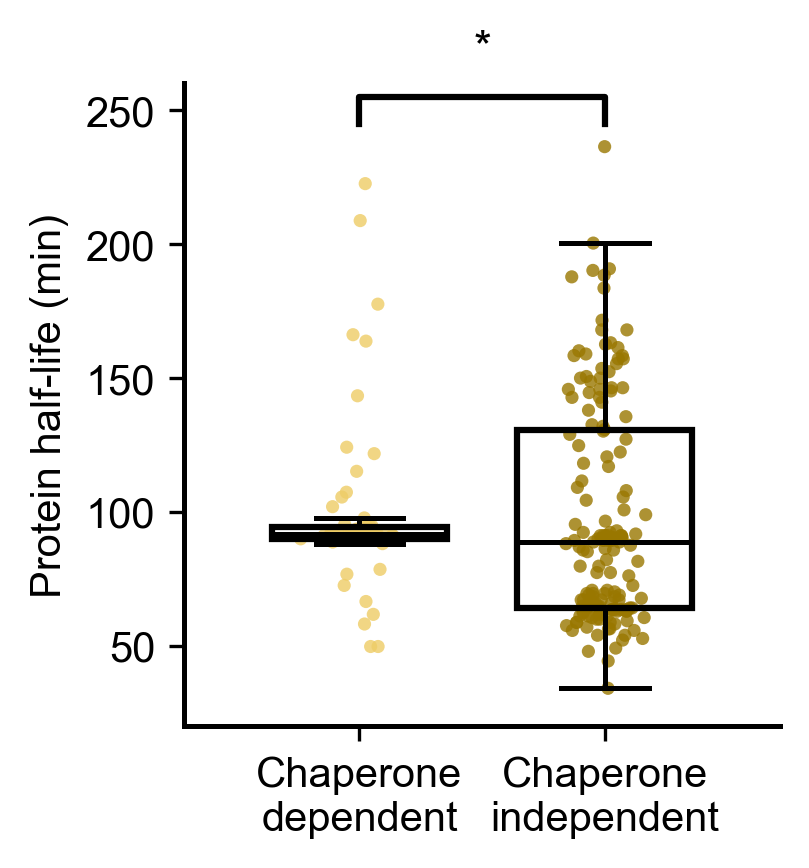

In [15]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y + 10
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top + 10,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )
    
fig, ax = plt.subplots(figsize=(2.8, 3))

group_vals   = [halflife_hub_chap, halflife_hub_nochap]
group_colors = [MS_COLOR_LIGHT, MS_COLOR_DARK]

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Chaperone\ndependent", "Chaperone\nindependent"],
    positions=positions,
    widths=0.5,
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)
        
#ax.set_yscale("log")
# Correct log ticks (10^1, 10^2, 10^3...)
#ax.yaxis.set_major_locator(ticker.LogLocator(base=10))
#ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation(base=10))
#ax.yaxis.set_minor_locator(ticker.NullLocator())


# --- LOG SCALE with compressed bottom ---
#ax.set_yscale("symlog", linthresh=130)
bracket_y = 245
ax.set_ylim(20, 260)


# --- Axes styling ---
ax.set_ylabel('Protein half-life (min)')

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)


# Set clean y-limits: from 0 down to a bit below the lowest value
y_min = min(halflife_hub_chap.min(), halflife_hub_nochap.min())
y_max = max(halflife_hub_chap.max(), halflife_hub_nochap.max())

# # Draw bracket
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "*")

# === Horizontal line + label EXACTLY ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()

# AE-MS group label under x-axis
#ax.plot(
#    [1.0, 1.7], [-0.24, -0.24],
#    transform=trans,
#    clip_on=False,
#    color=MS_COLOR,
#    lw=1.5,
#)

#ax.text(
#    1.35, -0.28, "AE-MS Hubs",
#    transform=trans,
#    ha="center",
#    va="top",
#    fontsize=10,
#    fontweight="bold",
#    color=MS_COLOR,
#)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig("6-C-TEMPORARY.svg")
plt.show()

## Figure 6C
* Boxplot of Turnover kinetics (t1/2 min) of chaperone associated static and dynamic hubs

In [16]:
# Hubs only
hub_df = final_df[final_df["is_hub"] == True].copy()

# Static vs Dynamic subsets
static_df  = hub_df[hub_df["hub_type"] == "static"].copy()
dynamic_df = hub_df[hub_df["hub_type"] == "dynamic"].copy()

# Clean values (replace inf, nan)
static_chap = static_df[static_df["has_chaperone"] == True]["Villen_halflife_min"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

static_nochap = static_df[static_df["has_chaperone"] == False]["Villen_halflife_min"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_chap = dynamic_df[dynamic_df["has_chaperone"] == True]["Villen_halflife_min"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_nochap = dynamic_df[dynamic_df["has_chaperone"] == False]["Villen_halflife_min"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

# Print counts 
groups_step3 = [
    ("Static + Chap",    static_chap,    MS_COLOR_LIGHT),
    ("Static + NoChap",  static_nochap,  MS_COLOR_DARK),
    ("Dynamic + Chap",   dynamic_chap,   MS_COLOR_LIGHT),
    ("Dynamic + NoChap", dynamic_nochap, MS_COLOR_DARK),
]

print("=== Protein counts in Degree Hubs (MS) ===")
for label, vals, _ in groups_step3:
    print(f"{label:18}: n = {len(vals)}")
 
# Bootstrapped medians 
print("\n=== Bootstrapped median half-life (95% CI) ===")
medians, ci_lowers, ci_uppers = [], [], []

for label, vals, color in groups_step3:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    print(f"{label:18}: median = {m:.1f}, 95% CI = ({lo:.1f}, {hi:.1f})")

=== Protein counts in Degree Hubs (MS) ===
Static + Chap     : n = 21
Static + NoChap   : n = 102
Dynamic + Chap    : n = 46
Dynamic + NoChap  : n = 55

=== Bootstrapped median half-life (95% CI) ===


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:12<00:00, 80974.53it/s]


Static + Chap     : median = 91.8, 95% CI = (91.2, 105.6)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 74594.34it/s]


Static + NoChap   : median = 90.6, 95% CI = (81.6, 117.0)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:12<00:00, 78105.88it/s]


Dynamic + Chap    : median = 91.2, 95% CI = (90.6, 92.4)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:12<00:00, 77753.48it/s]

Dynamic + NoChap  : median = 72.6, 95% CI = (63.6, 90.0)


In [17]:
# Mann–Whitney U tests
print("\n=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===")

def mwu_print(x, y, label):
    u, p = mannwhitneyu(x, y, alternative="two-sided")
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "N.S."
    print(f"{label:30}: U={u:.1f}, p={p:.3g}, significance={stars}")
    return stars

# 1. Within Static: Chaperone vs NoChaperone
stars_static = mwu_print(static_chap, static_nochap,
                         "Static+Chap vs Static+NoChap")

# 2. Within Dynamic: Chaperone vs NoChaperone
stars_dynamic = mwu_print(dynamic_chap, dynamic_nochap,
                          "Dynamic+Chap vs Dynamic+NoChap")

# 3. Between types (Chaperone only)
stars_chap = mwu_print(static_chap, dynamic_chap,
                       "Static+Chap vs Dynamic+Chap")

# 4. Between types (NoChaperone only)
stars_nochap = mwu_print(static_nochap, dynamic_nochap,
                         "Static+NoChap vs Dynamic+NoChap")

# ONE-SIDED Mann–Whitney U tests
print("\n=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===")

def mwu_print(x, y, label):
    u, p = mannwhitneyu(x, y, alternative="greater")
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "N.S."
    print(f"{label:30}: U={u:.1f}, p={p:.3g}, significance={stars}")
    return stars

# 1. Within Static: Chaperone vs NoChaperone
stars_static = mwu_print(static_chap, static_nochap,
                         "Static+Chap vs Static+NoChap")

# 2. Within Dynamic: Chaperone vs NoChaperone
stars_dynamic = mwu_print(dynamic_chap, dynamic_nochap,
                          "Dynamic+Chap vs Dynamic+NoChap")

# 3. Between types (Chaperone only)
stars_chap = mwu_print(static_chap, dynamic_chap,
                       "Static+Chap vs Dynamic+Chap")

# 4. Between types (NoChaperone only)
stars_nochap = mwu_print(static_nochap, dynamic_nochap,
                         "Static+NoChap vs Dynamic+NoChap")


=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===
Static+Chap vs Static+NoChap  : U=1256.0, p=0.215, significance=N.S.
Dynamic+Chap vs Dynamic+NoChap: U=1751.5, p=0.000908, significance=***
Static+Chap vs Dynamic+Chap   : U=611.5, p=0.0829, significance=N.S.
Static+NoChap vs Dynamic+NoChap: U=3744.5, p=0.00055, significance=***

=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===
Static+Chap vs Static+NoChap  : U=1256.0, p=0.107, significance=N.S.
Dynamic+Chap vs Dynamic+NoChap: U=1751.5, p=0.000454, significance=***
Static+Chap vs Dynamic+Chap   : U=611.5, p=0.0414, significance=*
Static+NoChap vs Dynamic+NoChap: U=3744.5, p=0.000275, significance=***


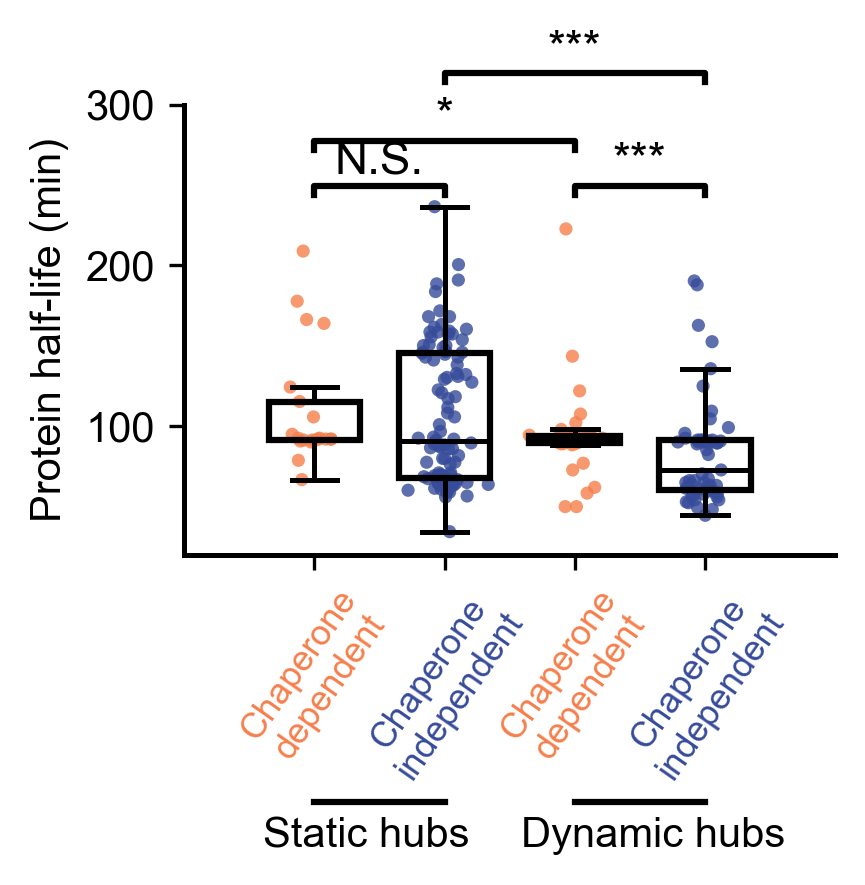

In [18]:
def add_bracket_axis(ax, x1, x2, y_axis, text):
    """
    Draw a bracket in AXIS coordinates.
    y_axis is a fraction of axis height (1.0 = top of plot).
    """
    trans = ax.get_xaxis_transform()  # x = data coords, y = axis coords (0–1)

    # bracket lines
    ax.plot([x1, x1, x2, x2],
            [y_axis, y_axis + 0.02, y_axis + 0.02, y_axis],
            transform=trans,
            lw=1.5, color="black", clip_on=False)

    # label
    ax.text((x1 + x2) / 2, y_axis + 0.025, text,
            transform=trans,
            ha="center", va="bottom",
            fontsize=11, clip_on=False)


fig, ax = plt.subplots(figsize=(2.8, 3))

positions = [0.7, 1.2, 1.7, 2.2]

group_data   = [static_chap, static_nochap, dynamic_chap, dynamic_nochap]
group_colors = ['#F67E4B', '#364B9A', '#F67E4B', '#364B9A']
group_labels = [
    "Chaperone\ndependent",
    "Chaperone\nindependent",
    "Chaperone\ndependent",
    "Chaperone\nindependent"
]

ax.set_xticks(positions)
ax.set_xticklabels(
    ["Chaperone\ndependent",
     "Chaperone\nindependent",
     "Chaperone\ndependent",
     "Chaperone\nindependent"],
    fontsize=10
)

# SCATTER 
for pos, (vals, color) in zip(positions, zip(group_data, group_colors)):
    jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        jitter, vals,
        s=10,
        alpha=0.8,          
        color=color,
        edgecolor="none",
        zorder=2
    )

# BOXPLOTS 
bp = ax.boxplot(
    group_data,
    positions=positions,
    widths=0.35,           
    patch_artist=True,
    showfliers=False
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# Y-AXIS STYLE 
#ax.set_yscale("symlog", linthresh=100)
ax.set_ylim(20, 300)
#ax.yaxis.set_major_locator(ticker.LogLocator(base=10))
#ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation(base=10))
#ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10), numticks=999))

ax.set_ylabel('Protein half-life (min)', fontsize=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

ax.set_xticks(positions)
ax.set_xticklabels(group_labels, fontsize=8.5, ha="center", rotation=55)

for label, color in zip(ax.get_xticklabels(), group_colors):
    label.set_color(color)

#AXIS-BASED SIGNIFICANCE BRACKETS
# lowest brackets (pairwise)
add_bracket_axis(ax, positions[0], positions[1], 0.80, stars_static)
add_bracket_axis(ax, positions[2], positions[3], 0.80, stars_dynamic)

# middle bracket (cross-chaperone)
add_bracket_axis(ax, positions[0], positions[2], 0.9, stars_chap)

# top bracket (cross-independent)
add_bracket_axis(ax, positions[1], positions[3], 1.05, stars_nochap)

# GROUP LABELS AT BOTTOM 
trans = ax.get_xaxis_transform()

ax.plot(
    [0.7, 1.2], [-0.55, -0.55], transform=trans, clip_on=False, color='black', lw=1.5)
ax.text(0.9, -0.65, "Static hubs",
        transform=trans, ha="center", fontsize=10, fontweight="normal")

ax.plot(
    [1.7, 2.2], [-0.55, -0.55], transform=trans, clip_on=False, color='black', lw=1.5)
ax.text(2.0, -0.65, "Dynamic hubs",
        transform=trans, ha="center", fontsize=10, fontweight="normal")

plt.subplots_adjust(bottom=0.38)
plt.savefig("6-C.svg", dpi=300, bbox_inches="tight")
plt.show()

## Figure 6E

* Boxplot of stability (Ghosh–Dill ΔG) of chaperone associated hubs and chaperone independent hubs

In [19]:
# Create a boolean for chaperone interaction
final_df["has_chaperone"] = final_df["num_chaperone_interactions"] > 0

# HUBS ONLY 
hub_df = final_df[final_df["is_hub"] == True].copy()

hub_chap     = hub_df[hub_df["has_chaperone"] == True]["Ghosh-Dill-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()
hub_nochap   = hub_df[hub_df["has_chaperone"] == False]["Ghosh-Dill-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

# Groups: (label, data, color)
groups = [
    ("Hub + Chaperone", hub_chap, MS_COLOR_LIGHT),
    ("Hub + No Chaperone", hub_nochap, MS_COLOR_DARK),
]

# Compute bootstrapped medians + CIs
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 76886.21it/s]


Hub + Chaperone: median=-7.15, 95% CI=(-8.14, -6.82), n=82)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 71969.95it/s]

Hub + No Chaperone: median=-8.45, 95% CI=(-9.03, -8.09), n=170)


In [20]:
# MWU test — Hub+Chap vs Hub+NoChap
ms_u, ms_p = mannwhitneyu(hub_chap, hub_nochap, alternative="two-sided")

print("=== Mann–Whitney U tests on Ghosh-Dill-dG ===")

print("\nMS Hub - Chaperone  associated vs MS Hub - Chaperone  independent")
print(f"n(chap) = {len(hub_chap)}, n(nochap) = {len(hub_nochap)}")
print(f"median(chap) = {np.median(hub_chap):.2f}, median(nochap) = {np.median(hub_nochap):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

# MWU test — Hub+Chap vs Hub+NoChap
ms_u, ms_p = mannwhitneyu(hub_chap, hub_nochap, alternative="less")

print("=== Mann–Whitney U tests on Ghosh-Dill-dG ===")

print("\nMS Hub - Chaperone  associated vs MS Hub - Chaperone  independent")
print(f"n(chap) = {len(hub_chap)}, n(nochap) = {len(hub_nochap)}")
print(f"median(chap) = {np.median(hub_chap):.2f}, median(nochap) = {np.median(hub_nochap):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

=== Mann–Whitney U tests on Ghosh-Dill-dG ===

MS Hub - Chaperone  associated vs MS Hub - Chaperone  independent
n(chap) = 82, n(nochap) = 170
median(chap) = -7.15, median(nochap) = -8.45
U = 8268.00, p = 0.01669
=== Mann–Whitney U tests on Ghosh-Dill-dG ===

MS Hub - Chaperone  associated vs MS Hub - Chaperone  independent
n(chap) = 82, n(nochap) = 170
median(chap) = -7.15, median(nochap) = -8.45
U = 8268.00, p = 0.9917


/tmp/ipykernel_2050/23595733.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


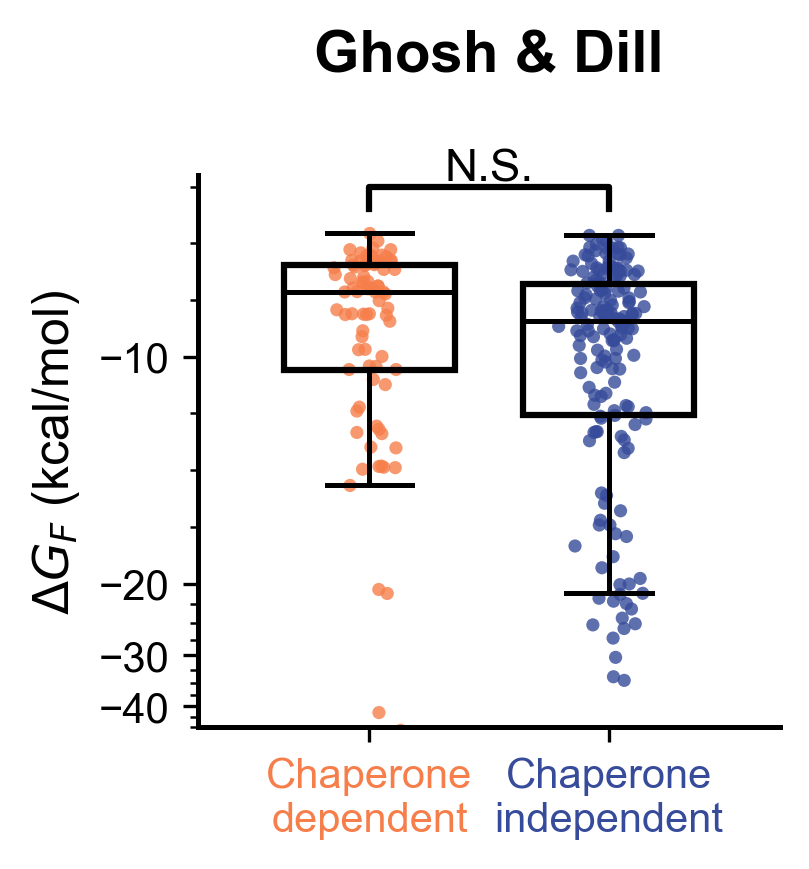

In [21]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y + 1
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top * 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )
    
fig, ax = plt.subplots(figsize=(2.8, 3))

group_vals   = [hub_chap, hub_nochap]
group_colors = ['#F67E4B', '#364B9A']

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Chaperone\ndependent", "Chaperone\nindependent"],
    positions=positions,
    widths=0.5,
    patch_artist=True,
    showfliers=False,
)

# Color x-axis tick labels
for label, color in zip(ax.get_xticklabels(), group_colors):
    label.set_color(color)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# Axes styling
ax.set_ylabel(r"$\Delta G_F$ (kcal/mol)", fontsize=12)
ax.set_title("Ghosh & Dill", fontweight='bold')
ax.set_yscale("symlog", linthresh=20)
ax.set_ylim(-45, -2)
ax.set_yticks([-10, -20, -30, -40])
ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
#ax.minorticks_on()
ax.yaxis.set_minor_locator(AutoMinorLocator(4))
bracket_y = -3.5
bracket_h = -0.05

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

# # Draw bracket
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "N.S.")

# === Horizontal line + label EXACTLY ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()

# AE-MS group label under x-axis
#ax.plot(
#    [1.0, 1.7], [-0.20, -0.20],
#    transform=trans,
#    clip_on=False,
#    color=MS_COLOR,
#    lw=1.5,
#)

#ax.text(
#    1.35, -0.24, "AE-MS Hubs",
#    transform=trans,
#    ha="center",
#    va="top",
#    fontsize=10,
#    fontweight="bold",
#    color=MS_COLOR,
#)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig("6-E.svg")
plt.show()

## Figure 6F
Boxplot of stability (Cagiada ΔG) of chaperone associated hubs and chaperone independent hubs

In [22]:
# Create a boolean for chaperone interaction
final_df["has_chaperone"] = final_df["num_chaperone_interactions"] > 0

# HUBS ONLY (degree-based MS hubs already computed)
hub_df = final_df[final_df["is_hub"] == True].copy()

hub_chap     = hub_df[hub_df["has_chaperone"] == True]["cagiada-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()
hub_nochap   = hub_df[hub_df["has_chaperone"] == False]["cagiada-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

# Groups: (label, data, color)
groups = [
    ("Hub + Chaperone", hub_chap, MS_COLOR_LIGHT),
    ("Hub + No Chaperone", hub_nochap, MS_COLOR_DARK),
]

# 2. Compute bootstrapped medians + CIs
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:12<00:00, 76953.71it/s]


Hub + Chaperone: median=-9.99, 95% CI=(-11.36, -8.06), n=82)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:14<00:00, 71376.41it/s]

Hub + No Chaperone: median=-12.86, 95% CI=(-13.79, -10.93), n=170)


In [23]:
# MWU test — Hub+Chap vs Hub+NoChap
ms_u, ms_p = mannwhitneyu(hub_chap, hub_nochap, alternative="two-sided")

print("=== Mann–Whitney U tests on cagiada-dG ===")

print("\nMS Hub - Chaperone  associated vs MS Hub - Chaperone  independent")
print(f"n(chap) = {len(hub_chap)}, n(nochap) = {len(hub_nochap)}")
print(f"median(chap) = {np.median(hub_chap):.2f}, median(nochap) = {np.median(hub_nochap):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

# MWU test — Hub+Chap vs Hub+NoChap
ms_u, ms_p = mannwhitneyu(hub_chap, hub_nochap, alternative="less")

print("=== Mann–Whitney U tests on cagiada-dG ===")

print("\nMS Hub - Chaperone  associated vs MS Hub - Chaperone  independent")
print(f"n(chap) = {len(hub_chap)}, n(nochap) = {len(hub_nochap)}")
print(f"median(chap) = {np.median(hub_chap):.2f}, median(nochap) = {np.median(hub_nochap):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

=== Mann–Whitney U tests on cagiada-dG ===

MS Hub - Chaperone  associated vs MS Hub - Chaperone  independent
n(chap) = 82, n(nochap) = 170
median(chap) = -9.99, median(nochap) = -12.86
U = 7532.00, p = 0.3003
=== Mann–Whitney U tests on cagiada-dG ===

MS Hub - Chaperone  associated vs MS Hub - Chaperone  independent
n(chap) = 82, n(nochap) = 170
median(chap) = -9.99, median(nochap) = -12.86
U = 7532.00, p = 0.8503


/tmp/ipykernel_2050/3144372951.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


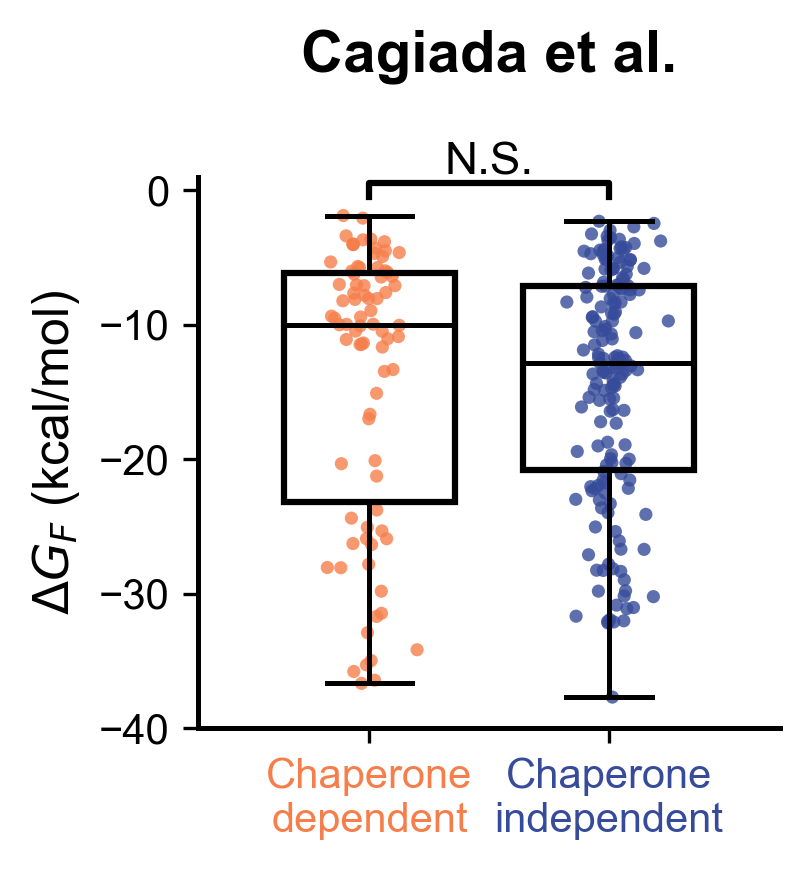

In [24]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y + 1
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top * 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )
    
fig, ax = plt.subplots(figsize=(2.8, 3))

group_vals   = [hub_chap, hub_nochap]
group_colors = ['#F67E4B', '#364B9A']

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Chaperone\ndependent", "Chaperone\nindependent"],
    positions=positions,
    widths=0.5,
    patch_artist=True,
    showfliers=False,
)

# Color x-axis tick labels
for label, color in zip(ax.get_xticklabels(), group_colors):
    label.set_color(color)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# --- Axes styling ---
ax.set_ylabel(r"$\Delta G_F$ (kcal/mol)", fontsize=12)
ax.set_title("Cagiada et al.", fontweight='bold')
ax.set_ylim(-40, 1)
ax.set_yticks([0, -10, -20, -30, -40])
bracket_y = -0.5
bracket_h = -0.5

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

# # Draw bracket
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "N.S.")

# === Horizontal line + label ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()

# AE-MS group label under x-axis
#ax.plot(
#    [1.0, 1.7], [-0.20, -0.20],
#    transform=trans,
#    clip_on=False,
#    color=MS_COLOR,
#    lw=1.5,
#)

#ax.text(
#    1.35, -0.24, "AE-MS Hubs",
#    transform=trans,
#    ha="center",
#    va="top",
#    fontsize=10,
#    fontweight="bold",
#    color=MS_COLOR,
#)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig("6-F.svg")
plt.show()

## Figure 6D
Boxplot of stability (Rosetta Total Score) of chaperone associated hubs and chaperone independent hubs

In [25]:
# Create a boolean for chaperone interaction
final_df["has_chaperone"] = final_df["num_chaperone_interactions"] > 0

# HUBS ONLY 
hub_df = final_df[final_df["is_hub"] == True].copy()

rosetta_hub_chap     = hub_df[hub_df["has_chaperone"] == True]["Rosetta_best_total_score"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()
rosetta_hub_nochap   = hub_df[hub_df["has_chaperone"] == False]["Rosetta_best_total_score"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

# Groups
groups = [
    ("Hub + Chaperone", rosetta_hub_chap, MS_COLOR_LIGHT),
    ("Hub + No Chaperone", rosetta_hub_nochap, MS_COLOR_DARK),
]

# 2. Compute bootstrapped medians + CIs
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 76593.54it/s]


Hub + Chaperone: median=-537.69, 95% CI=(-669.16, -451.99), n=82)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 72180.13it/s]


Hub + No Chaperone: median=-746.83, 95% CI=(-816.20, -654.67), n=170)


In [26]:
# MWU test — Hub+Chap vs Hub+NoChap
ms_u, ms_p = mannwhitneyu(rosetta_hub_chap, rosetta_hub_nochap, alternative="two-sided")

print("=== Mann–Whitney U tests on Rosetta_best_total_score ===")

print("\nMS Hub - Chaperone  associated vs MS Hub - Chaperone  independent")
print(f"n(chap) = {len(rosetta_hub_chap)}, n(nochap) = {len(rosetta_hub_nochap)}")
print(f"median(chap) = {np.median(rosetta_hub_chap):.2f}, median(nochap) = {np.median(rosetta_hub_nochap):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")


# MWU test — Hub+Chap vs Hub+NoChap
ms_u, ms_p = mannwhitneyu(rosetta_hub_chap, rosetta_hub_nochap, alternative="less")

print("=== Mann–Whitney U tests on Rosetta_best_total_score ===")

print("\nMS Hub - Chaperone  associated vs MS Hub - Chaperone  independent")
print(f"n(chap) = {len(rosetta_hub_chap)}, n(nochap) = {len(rosetta_hub_nochap)}")
print(f"median(chap) = {np.median(rosetta_hub_chap):.2f}, median(nochap) = {np.median(rosetta_hub_nochap):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

=== Mann–Whitney U tests on Rosetta_best_total_score ===

MS Hub - Chaperone  associated vs MS Hub - Chaperone  independent
n(chap) = 82, n(nochap) = 170
median(chap) = -537.69, median(nochap) = -746.83
U = 8112.00, p = 0.03524
=== Mann–Whitney U tests on Rosetta_best_total_score ===

MS Hub - Chaperone  associated vs MS Hub - Chaperone  independent
n(chap) = 82, n(nochap) = 170
median(chap) = -537.69, median(nochap) = -746.83
U = 8112.00, p = 0.9825


/tmp/ipykernel_2050/2686106830.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


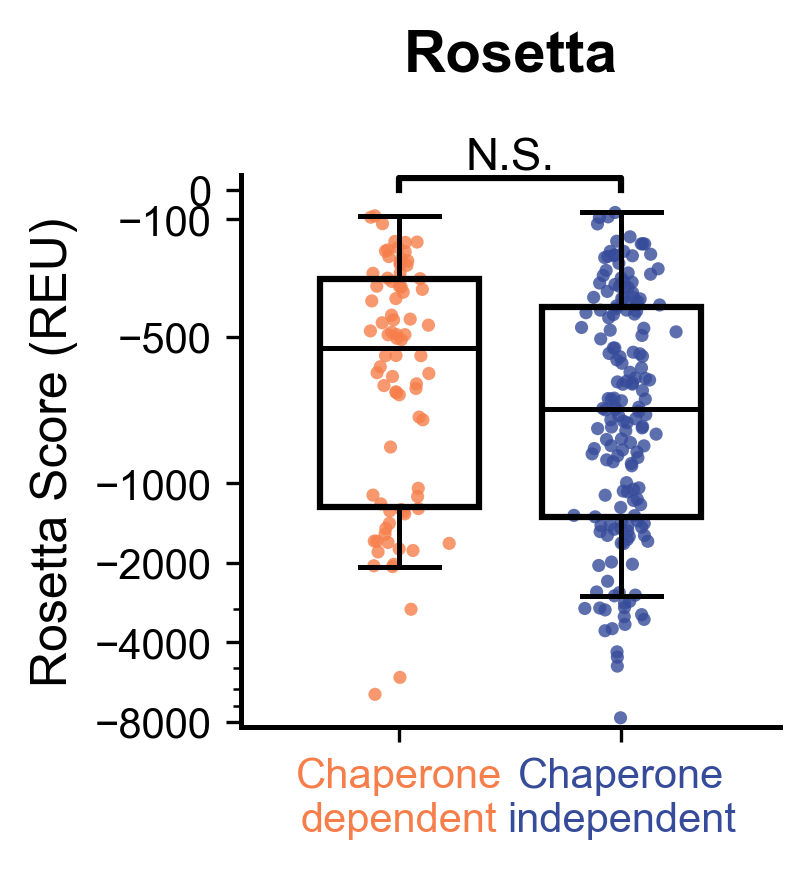

In [27]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y + 40
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top / 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )
    
fig, ax = plt.subplots(figsize=(2.8, 3))

group_vals   = [rosetta_hub_chap, rosetta_hub_nochap]
group_colors = ['#F67E4B', '#364B9A']

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Chaperone\ndependent", "Chaperone\nindependent"],
    positions=positions,
    widths=0.5,
    patch_artist=True,
    showfliers=False,
)

# Color x-axis tick labels
for label, color in zip(ax.get_xticklabels(), group_colors):
    label.set_color(color)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# --- Axes styling ---
ax.set_ylabel("Rosetta Score (REU)", fontsize=12)
ax.set_title("Rosetta", fontweight='bold')
ax.set_yscale("symlog", linthresh=1000)
ax.set_ylim(-8400, 50)
ax.set_yticks([-8000, -4000, -2000, -1000, -500, -100, 0])
ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
#ax.minorticks_on()
ax.yaxis.set_minor_locator(AutoMinorLocator(4))
bracket_y = 0   
bracket_h = 4

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

# Place significance bracket at a fixed, nice height just above 0
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "N.S.")

# === Horizontal line + label ==
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()

# AE-MS group label under x-axis
#ax.plot(
#    [1.0, 1.7], [-0.22, -0.22],
#    transform=trans,
#    clip_on=False,
#    color=MS_COLOR,
#    lw=1.5,
#)

#ax.text(
#    1.35, -0.26, "AE-MS Hubs",
#    transform=trans,
#    ha="center",
#    va="top",
#    fontsize=10,
#    fontweight="bold",
#    color=MS_COLOR,
#)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig("6-D.svg")
plt.show()

## Figure 6G
Boxplot of Meltome melting point of chaperone associated hubs and chaperone independent hubs

In [28]:
# Create a boolean for chaperone interaction
final_df["has_chaperone"] = final_df["num_chaperone_interactions"] > 0

# HUBS ONLY (degree-based MS hubs already computed)
hub_df = final_df[final_df["is_hub"] == True].copy()

# Clean Ghosh–Dill values
hub_df["meltome-melting-point"] = hub_df[hub_df['meltome-fit-R2'] > 0.9]["meltome-melting-point"].replace([np.inf, -np.inf], np.nan).dropna()

hub_chap     = hub_df[hub_df["has_chaperone"] == True]["meltome-melting-point"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()
hub_nochap   = hub_df[hub_df["has_chaperone"] == False]["meltome-melting-point"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

# Groups: (label, data, color)
groups = [
    ("Hub + Chaperone", hub_chap, MS_COLOR_LIGHT),
    ("Hub + No Chaperone", hub_nochap, MS_COLOR_DARK),
]

# 2. Compute bootstrapped medians + CIs
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:12<00:00, 78605.51it/s]


Hub + Chaperone: median=42.96, 95% CI=(42.37, 44.72), n=69)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:12<00:00, 77064.04it/s]

Hub + No Chaperone: median=44.91, 95% CI=(44.31, 47.51), n=109)


In [29]:
# MWU test — Hub+Chap vs Hub+NoChap
ms_u, ms_p = mannwhitneyu(hub_chap, hub_nochap, alternative="two-sided")

print("=== Mann–Whitney U tests on meltome-melting-point ===")

print("\nMS Hub - Chaperone  associated vs MS Hub - Chaperone  independent")
print(f"n(chap) = {len(hub_chap)}, n(nochap) = {len(hub_nochap)}")
print(f"median(chap) = {np.median(hub_chap):.2f}, median(nochap) = {np.median(hub_nochap):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

# MWU test — Hub+Chap vs Hub+NoChap
ms_u, ms_p = mannwhitneyu(hub_chap, hub_nochap, alternative="less")

print("=== Mann–Whitney U tests on meltome-melting-point ===")

print("\nMS Hub - Chaperone  associated vs MS Hub - Chaperone  independent")
print(f"n(chap) = {len(hub_chap)}, n(nochap) = {len(hub_nochap)}")
print(f"median(chap) = {np.median(hub_chap):.2f}, median(nochap) = {np.median(hub_nochap):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

=== Mann–Whitney U tests on meltome-melting-point ===

MS Hub - Chaperone  associated vs MS Hub - Chaperone  independent
n(chap) = 69, n(nochap) = 109
median(chap) = 42.96, median(nochap) = 44.91
U = 2578.50, p = 0.0004195
=== Mann–Whitney U tests on meltome-melting-point ===

MS Hub - Chaperone  associated vs MS Hub - Chaperone  independent
n(chap) = 69, n(nochap) = 109
median(chap) = 42.96, median(nochap) = 44.91
U = 2578.50, p = 0.0002098


/tmp/ipykernel_2050/1492146978.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


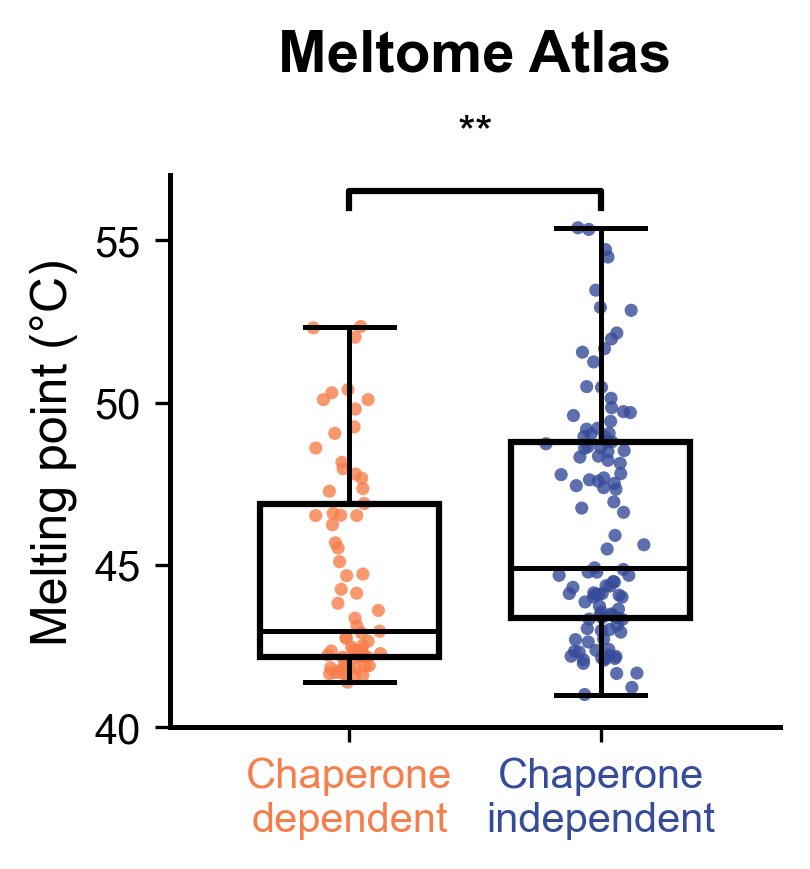

In [30]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y + 0.5
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top + 1.1,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )
    
fig, ax = plt.subplots(figsize=(2.8, 3))

group_vals   = [hub_chap, hub_nochap]
group_colors = ['#F67E4B', '#364B9A']

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Chaperone\ndependent", "Chaperone\nindependent"],
    positions=positions,
    widths=0.5,
    patch_artist=True,
    showfliers=False,
)

# Color x-axis tick labels
for label, color in zip(ax.get_xticklabels(), group_colors):
    label.set_color(color)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# --- Axes styling ---
ax.set_ylabel("Melting point (°C)", fontsize=12)
ax.set_title("Meltome Atlas", fontweight='bold')
ax.set_ylim(40, 57)
ax.set_yticks([40, 45, 50, 55])
bracket_y = 56
bracket_h = 0.05

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

# # Draw bracket
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "***")

# === Horizontal line + label ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()

# AE-MS group label under x-axis
#ax.plot(
#    [1.0, 1.7], [-0.24, -0.24],
#    transform=trans,
#    clip_on=False,
#    color=MS_COLOR,
#    lw=1.5,
#)

#ax.text(
#    1.35, -0.28, "AE-MS Hubs",
#    transform=trans,
#    ha="center",
#    va="top",
#    fontsize=10,
#    fontweight="bold",
#    color=MS_COLOR,
#)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig("6-G.svg")
plt.show()

In [31]:
# Prepare Static/Dynamic + Chaperone Groups for Melting point Tm

# Hubs only
hub_df = final_df[final_df["is_hub"] == True].copy()

# Filter Meltome to high-confidence fits
hub_df = hub_df[hub_df["meltome-fit-R2"] > 0.9].copy()

# Convert meltome to numeric and clean
hub_df["meltome-melting-point"] = pd.to_numeric(
    hub_df["meltome-melting-point"], errors="coerce"
)

# Static vs Dynamic subsets
static_df  = hub_df[hub_df["hub_type"] == "static"].copy()
dynamic_df = hub_df[hub_df["hub_type"] == "dynamic"].copy()

# Clean values (replace inf, nan)
static_chap = static_df[static_df["has_chaperone"] == True]["meltome-melting-point"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

static_nochap = static_df[static_df["has_chaperone"] == False]["meltome-melting-point"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_chap = dynamic_df[dynamic_df["has_chaperone"] == True]["meltome-melting-point"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_nochap = dynamic_df[dynamic_df["has_chaperone"] == False]["meltome-melting-point"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

# Print counts 
groups_step3 = [
    ("Static + Chap",    static_chap,    MS_COLOR_LIGHT),
    ("Static + NoChap",  static_nochap,  MS_COLOR_DARK),
    ("Dynamic + Chap",   dynamic_chap,   MS_COLOR_LIGHT),
    ("Dynamic + NoChap", dynamic_nochap, MS_COLOR_DARK),
]

print("=== Protein counts in Degree Hubs (MS) ===")
for label, vals, _ in groups_step3:
    print(f"{label:18}: n = {len(vals)}")

# Bootstrapped medians 
print("\n=== Bootstrapped median meltome-melting-point (95% CI) ===")
medians, ci_lowers, ci_uppers = [], [], []

for label, vals, color in groups_step3:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    print(f"{label:18}: median = {m:.1f} °C, 95% CI = ({lo:.1f}, {hi:.1f})")

=== Protein counts in Degree Hubs (MS) ===
Static + Chap     : n = 21
Static + NoChap   : n = 61
Dynamic + Chap    : n = 48
Dynamic + NoChap  : n = 48

=== Bootstrapped median meltome-melting-point (95% CI) ===


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:12<00:00, 81160.97it/s]


Static + Chap     : median = 45.7 °C, 95% CI = (42.3, 47.4)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:12<00:00, 78399.24it/s]


Static + NoChap   : median = 47.4 °C, 95% CI = (44.7, 48.7)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:12<00:00, 79813.67it/s]


Dynamic + Chap    : median = 42.7 °C, 95% CI = (42.2, 44.2)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:12<00:00, 80695.99it/s]

Dynamic + NoChap  : median = 44.1 °C, 95% CI = (43.3, 46.6)


In [32]:
# Mann–Whitney U tests
print("\n=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===")

def mwu_print(x, y, label):
    u, p = mannwhitneyu(x, y, alternative="two-sided")
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "N.S."
    print(f"{label:30}: U={u:.1f}, p={p:.3g}, significance={stars}")
    return stars

# 1. Within Static: Chaperone vs NoChaperone
stars_static = mwu_print(static_chap, static_nochap,
                         "Static+Chap vs Static+NoChap")

# 2. Within Dynamic: Chaperone vs NoChaperone
stars_dynamic = mwu_print(dynamic_chap, dynamic_nochap,
                          "Dynamic+Chap vs Dynamic+NoChap")

# 3. Between types (Chaperone only)
stars_chap = mwu_print(static_chap, dynamic_chap,
                       "Static+Chap vs Dynamic+Chap")

# 4. Between types (NoChaperone only)
stars_nochap = mwu_print(static_nochap, dynamic_nochap,
                         "Static+NoChap vs Dynamic+NoChap")


# Mann–Whitney U tests
print("\n=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===")

def mwu_print(x, y, label):
    u, p = mannwhitneyu(x, y, alternative="greater")
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "N.S."
    print(f"{label:30}: U={u:.1f}, p={p:.3g}, significance={stars}")
    return stars

# 1. Within Static: Chaperone vs NoChaperone
stars_static = mwu_print(static_chap, static_nochap,
                         "Static+Chap vs Static+NoChap")

# 2. Within Dynamic: Chaperone vs NoChaperone
stars_dynamic = mwu_print(dynamic_chap, dynamic_nochap,
                          "Dynamic+Chap vs Dynamic+NoChap")

# 3. Between types (Chaperone only)
stars_chap = mwu_print(static_chap, dynamic_chap,
                       "Static+Chap vs Dynamic+Chap")

# 4. Between types (NoChaperone only)
stars_nochap = mwu_print(static_nochap, dynamic_nochap,
                         "Static+NoChap vs Dynamic+NoChap")


=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===
Static+Chap vs Static+NoChap  : U=454.5, p=0.0488, significance=*
Dynamic+Chap vs Dynamic+NoChap: U=886.5, p=0.0522, significance=N.S.
Static+Chap vs Dynamic+Chap   : U=582.5, p=0.309, significance=N.S.
Static+NoChap vs Dynamic+NoChap: U=1909.0, p=0.00666, significance=**

=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===
Static+Chap vs Static+NoChap  : U=454.5, p=0.976, significance=N.S.
Dynamic+Chap vs Dynamic+NoChap: U=886.5, p=0.974, significance=N.S.
Static+Chap vs Dynamic+Chap   : U=582.5, p=0.155, significance=N.S.
Static+NoChap vs Dynamic+NoChap: U=1909.0, p=0.00333, significance=**


In [33]:
# Prepare Static/Dynamic + Chaperone Groups for Rosetta Total Score

# Hubs only
hub_df = final_df[final_df["is_hub"] == True].copy()

# Clean Rosetta score column ONCE
hub_df["Rosetta_best_total_score"] = (
    pd.to_numeric(hub_df["Rosetta_best_total_score"], errors='coerce')
      .replace([np.inf, -np.inf], np.nan)
)

# Static vs Dynamic subsets
static_df  = hub_df[hub_df["hub_type"] == "static"].copy()
dynamic_df = hub_df[hub_df["hub_type"] == "dynamic"].copy()

# Clean values (replace inf, nan)
static_chap = static_df[static_df["has_chaperone"] == True]["Rosetta_best_total_score"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

static_nochap = static_df[static_df["has_chaperone"] == False]["Rosetta_best_total_score"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_chap = dynamic_df[dynamic_df["has_chaperone"] == True]["Rosetta_best_total_score"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_nochap = dynamic_df[dynamic_df["has_chaperone"] == False]["Rosetta_best_total_score"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

# Print counts 
groups_step3 = [
    ("Static + Chap",    static_chap,    MS_COLOR_LIGHT),
    ("Static + NoChap",  static_nochap,  MS_COLOR_DARK),
    ("Dynamic + Chap",   dynamic_chap,   MS_COLOR_LIGHT),
    ("Dynamic + NoChap", dynamic_nochap, MS_COLOR_DARK),
]

print("=== Protein counts in Degree Hubs (MS) ===")
for label, vals, _ in groups_step3:
    print(f"{label:18}: n = {len(vals)}")


# Bootstrapped medians 
print("\n=== Bootstrapped median Rosetta_best_total_score (95% CI) ===")
medians, ci_lowers, ci_uppers = [], [], []

for label, vals, color in groups_step3:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    print(f"{label:18}: median = {m:.1f} kcal/mol, 95% CI = ({lo:.1f}, {hi:.1f})")

=== Protein counts in Degree Hubs (MS) ===
Static + Chap     : n = 26
Static + NoChap   : n = 108
Dynamic + Chap    : n = 56
Dynamic + NoChap  : n = 62

=== Bootstrapped median Rosetta_best_total_score (95% CI) ===


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:12<00:00, 80597.31it/s]


Static + Chap     : median = -779.1 kcal/mol, 95% CI = (-1260.1, -348.9)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 76554.84it/s]


Static + NoChap   : median = -749.3 kcal/mol, 95% CI = (-910.1, -653.0)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:12<00:00, 79108.77it/s]


Dynamic + Chap    : median = -493.5 kcal/mol, 95% CI = (-584.1, -428.0)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:12<00:00, 79468.30it/s]

Dynamic + NoChap  : median = -728.1 kcal/mol, 95% CI = (-821.1, -557.6)


In [34]:
# Mann–Whitney U tests
print("\n=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===")

def mwu_print(x, y, label):
    u, p = mannwhitneyu(x, y, alternative="two-sided")
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "N.S."
    print(f"{label:30}: U={u:.1f}, p={p:.3g}, significance={stars}")
    return stars

# 1. Within Static: Chaperone vs NoChaperone
stars_static = mwu_print(static_chap, static_nochap,
                         "Static+Chap vs Static+NoChap")

# 2. Within Dynamic: Chaperone vs NoChaperone
stars_dynamic = mwu_print(dynamic_chap, dynamic_nochap,
                          "Dynamic+Chap vs Dynamic+NoChap")

# 3. Between types (Chaperone only)
stars_chap = mwu_print(static_chap, dynamic_chap,
                       "Static+Chap vs Dynamic+Chap")

# 4. Between types (NoChaperone only)
stars_nochap = mwu_print(static_nochap, dynamic_nochap,
                         "Static+NoChap vs Dynamic+NoChap")



# Mann–Whitney U tests
print("\n=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===")

def mwu_print(x, y, label):
    u, p = mannwhitneyu(x, y, alternative="greater")
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "N.S."
    print(f"{label:30}: U={u:.1f}, p={p:.3g}, significance={stars}")
    return stars

# 1. Within Static: Chaperone vs NoChaperone
stars_static = mwu_print(static_chap, static_nochap,
                         "Static+Chap vs Static+NoChap")

# 2. Within Dynamic: Chaperone vs NoChaperone
stars_dynamic = mwu_print(dynamic_chap, dynamic_nochap,
                          "Dynamic+Chap vs Dynamic+NoChap")

# 3. Between types (Chaperone only)
stars_chap = mwu_print(static_chap, dynamic_chap,
                       "Static+Chap vs Dynamic+Chap")

# 4. Between types (NoChaperone only)
stars_nochap = mwu_print(static_nochap, dynamic_nochap,
                         "Static+NoChap vs Dynamic+NoChap")


=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===
Static+Chap vs Static+NoChap  : U=1454.0, p=0.781, significance=N.S.
Dynamic+Chap vs Dynamic+NoChap: U=2040.0, p=0.102, significance=N.S.
Static+Chap vs Dynamic+Chap   : U=575.0, p=0.129, significance=N.S.
Static+NoChap vs Dynamic+NoChap: U=2951.0, p=0.199, significance=N.S.

=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===
Static+Chap vs Static+NoChap  : U=1454.0, p=0.39, significance=N.S.
Dynamic+Chap vs Dynamic+NoChap: U=2040.0, p=0.051, significance=N.S.
Static+Chap vs Dynamic+Chap   : U=575.0, p=0.937, significance=N.S.
Static+NoChap vs Dynamic+NoChap: U=2951.0, p=0.901, significance=N.S.


In [35]:
# Prepare Static/Dynamic + Chaperone Groups for Cagiada-dG

# Hubs only
hub_df = final_df[final_df["is_hub"] == True].copy()

# Clean Rosetta score column ONCE
hub_df["cagiada-dG"] = (
    pd.to_numeric(hub_df["cagiada-dG"], errors='coerce')
      .replace([np.inf, -np.inf], np.nan)
)

# Static vs Dynamic subsets
static_df  = hub_df[hub_df["hub_type"] == "static"].copy()
dynamic_df = hub_df[hub_df["hub_type"] == "dynamic"].copy()

# Clean values (replace inf, nan)
static_chap = static_df[static_df["has_chaperone"] == True]["cagiada-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

static_nochap = static_df[static_df["has_chaperone"] == False]["cagiada-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_chap = dynamic_df[dynamic_df["has_chaperone"] == True]["cagiada-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_nochap = dynamic_df[dynamic_df["has_chaperone"] == False]["cagiada-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

# Print counts 
groups_step3 = [
    ("Static + Chap",    static_chap,    MS_COLOR_LIGHT),
    ("Static + NoChap",  static_nochap,  MS_COLOR_DARK),
    ("Dynamic + Chap",   dynamic_chap,   MS_COLOR_LIGHT),
    ("Dynamic + NoChap", dynamic_nochap, MS_COLOR_DARK),
]

print("=== Protein counts in Degree Hubs (MS) ===")
for label, vals, _ in groups_step3:
    print(f"{label:18}: n = {len(vals)}")

# Bootstrapped medians 
print("\n=== Bootstrapped median cagiada-dG (95% CI) ===")
medians, ci_lowers, ci_uppers = [], [], []

for label, vals, color in groups_step3:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    print(f"{label:18}: median = {m:.1f} kcal/mol, 95% CI = ({lo:.1f}, {hi:.1f})")

=== Protein counts in Degree Hubs (MS) ===
Static + Chap     : n = 26
Static + NoChap   : n = 108
Dynamic + Chap    : n = 56
Dynamic + NoChap  : n = 62

=== Bootstrapped median cagiada-dG (95% CI) ===


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:12<00:00, 81016.00it/s]


Static + Chap     : median = -14.3 kcal/mol, 95% CI = (-24.4, -9.6)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 76828.26it/s]


Static + NoChap   : median = -13.5 kcal/mol, 95% CI = (-16.2, -11.3)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:12<00:00, 79595.13it/s]


Dynamic + Chap    : median = -9.2 kcal/mol, 95% CI = (-10.3, -7.1)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:12<00:00, 78870.75it/s]

Dynamic + NoChap  : median = -12.4 kcal/mol, 95% CI = (-13.2, -9.2)


In [36]:
# Mann–Whitney U tests
print("\n=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===")

def mwu_print(x, y, label):
    u, p = mannwhitneyu(x, y, alternative="two-sided")
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "N.S."
    print(f"{label:30}: U={u:.1f}, p={p:.3g}, significance={stars}")
    return stars

# 1. Within Static: Chaperone vs NoChaperone
stars_static = mwu_print(static_chap, static_nochap,
                         "Static+Chap vs Static+NoChap")

# 2. Within Dynamic: Chaperone vs NoChaperone
stars_dynamic = mwu_print(dynamic_chap, dynamic_nochap,
                          "Dynamic+Chap vs Dynamic+NoChap")

# 3. Between types (Chaperone only)
stars_chap = mwu_print(static_chap, dynamic_chap,
                       "Static+Chap vs Dynamic+Chap")

# 4. Between types (NoChaperone only)
stars_nochap = mwu_print(static_nochap, dynamic_nochap,
                         "Static+NoChap vs Dynamic+NoChap")



# Mann–Whitney U tests
print("\n=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===")

def mwu_print(x, y, label):
    u, p = mannwhitneyu(x, y, alternative="greater")
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "N.S."
    print(f"{label:30}: U={u:.1f}, p={p:.3g}, significance={stars}")
    return stars

# 1. Within Static: Chaperone vs NoChaperone
stars_static = mwu_print(static_chap, static_nochap,
                         "Static+Chap vs Static+NoChap")

# 2. Within Dynamic: Chaperone vs NoChaperone
stars_dynamic = mwu_print(dynamic_chap, dynamic_nochap,
                          "Dynamic+Chap vs Dynamic+NoChap")

# 3. Between types (Chaperone only)
stars_chap = mwu_print(static_chap, dynamic_chap,
                       "Static+Chap vs Dynamic+Chap")

# 4. Between types (NoChaperone only)
stars_nochap = mwu_print(static_nochap, dynamic_nochap,
                         "Static+NoChap vs Dynamic+NoChap")


=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===
Static+Chap vs Static+NoChap  : U=1281.0, p=0.491, significance=N.S.
Dynamic+Chap vs Dynamic+NoChap: U=1942.0, p=0.268, significance=N.S.
Static+Chap vs Dynamic+Chap   : U=522.0, p=0.0406, significance=*
Static+NoChap vs Dynamic+NoChap: U=2824.0, p=0.0901, significance=N.S.

=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===
Static+Chap vs Static+NoChap  : U=1281.0, p=0.756, significance=N.S.
Dynamic+Chap vs Dynamic+NoChap: U=1942.0, p=0.134, significance=N.S.
Static+Chap vs Dynamic+Chap   : U=522.0, p=0.98, significance=N.S.
Static+NoChap vs Dynamic+NoChap: U=2824.0, p=0.955, significance=N.S.


In [37]:
# Prepare Static/Dynamic + Chaperone Groups for Ghosh-Dill-dG

# Hubs only
hub_df = final_df[final_df["is_hub"] == True].copy()

# Clean column ONCE
hub_df["Ghosh-Dill-dG"] = (
    pd.to_numeric(hub_df["Ghosh-Dill-dG"], errors='coerce')
      .replace([np.inf, -np.inf], np.nan)
)

# Static vs Dynamic subsets
static_df  = hub_df[hub_df["hub_type"] == "static"].copy()
dynamic_df = hub_df[hub_df["hub_type"] == "dynamic"].copy()

# Clean values (replace inf, nan)
static_chap = static_df[static_df["has_chaperone"] == True]["Ghosh-Dill-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

static_nochap = static_df[static_df["has_chaperone"] == False]["Ghosh-Dill-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_chap = dynamic_df[dynamic_df["has_chaperone"] == True]["Ghosh-Dill-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_nochap = dynamic_df[dynamic_df["has_chaperone"] == False]["Ghosh-Dill-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

# Print counts 
groups_step3 = [
    ("Static + Chap",    static_chap,    MS_COLOR_LIGHT),
    ("Static + NoChap",  static_nochap,  MS_COLOR_DARK),
    ("Dynamic + Chap",   dynamic_chap,   MS_COLOR_LIGHT),
    ("Dynamic + NoChap", dynamic_nochap, MS_COLOR_DARK),
]

print("=== Protein counts in Degree Hubs (MS) ===")
for label, vals, _ in groups_step3:
    print(f"{label:18}: n = {len(vals)}")

# Bootstrapped medians 
print("\n=== Bootstrapped median meltome-melting-point (95% CI) ===")
medians, ci_lowers, ci_uppers = [], [], []

for label, vals, color in groups_step3:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    print(f"{label:18}: median = {m:.1f} °C, 95% CI = ({lo:.1f}, {hi:.1f})")

=== Protein counts in Degree Hubs (MS) ===
Static + Chap     : n = 26
Static + NoChap   : n = 108
Dynamic + Chap    : n = 56
Dynamic + NoChap  : n = 62

=== Bootstrapped median meltome-melting-point (95% CI) ===


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:12<00:00, 79984.12it/s]


Static + Chap     : median = -9.0 °C, 95% CI = (-11.0, -6.2)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 75450.56it/s]


Static + NoChap   : median = -8.8 °C, 95% CI = (-10.0, -8.3)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:12<00:00, 79523.48it/s]


Dynamic + Chap    : median = -7.0 °C, 95% CI = (-8.0, -6.7)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:12<00:00, 79134.86it/s]

Dynamic + NoChap  : median = -8.1 °C, 95% CI = (-8.5, -7.3)


In [38]:
# Mann–Whitney U tests
print("\n=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===")

def mwu_print(x, y, label):
    u, p = mannwhitneyu(x, y, alternative="two-sided")
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "N.S."
    print(f"{label:30}: U={u:.1f}, p={p:.3g}, significance={stars}")
    return stars

# 1. Within Static: Chaperone vs NoChaperone
stars_static = mwu_print(static_chap, static_nochap,
                         "Static+Chap vs Static+NoChap")

# 2. Within Dynamic: Chaperone vs NoChaperone
stars_dynamic = mwu_print(dynamic_chap, dynamic_nochap,
                          "Dynamic+Chap vs Dynamic+NoChap")

# 3. Between types (Chaperone only)
stars_chap = mwu_print(static_chap, dynamic_chap,
                       "Static+Chap vs Dynamic+Chap")

# 4. Between types (NoChaperone only)
stars_nochap = mwu_print(static_nochap, dynamic_nochap,
                         "Static+NoChap vs Dynamic+NoChap")



# Mann–Whitney U tests
print("\n=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===")

def mwu_print(x, y, label):
    u, p = mannwhitneyu(x, y, alternative="greater")
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "N.S."
    print(f"{label:30}: U={u:.1f}, p={p:.3g}, significance={stars}")
    return stars

# 1. Within Static: Chaperone vs NoChaperone
stars_static = mwu_print(static_chap, static_nochap,
                         "Static+Chap vs Static+NoChap")

# 2. Within Dynamic: Chaperone vs NoChaperone
stars_dynamic = mwu_print(dynamic_chap, dynamic_nochap,
                          "Dynamic+Chap vs Dynamic+NoChap")

# 3. Between types (Chaperone only)
stars_chap = mwu_print(static_chap, dynamic_chap,
                       "Static+Chap vs Dynamic+Chap")

# 4. Between types (NoChaperone only)
stars_nochap = mwu_print(static_nochap, dynamic_nochap,
                         "Static+NoChap vs Dynamic+NoChap")


=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===
Static+Chap vs Static+NoChap  : U=1542.5, p=0.437, significance=N.S.
Dynamic+Chap vs Dynamic+NoChap: U=2010.0, p=0.14, significance=N.S.
Static+Chap vs Dynamic+Chap   : U=606.0, p=0.226, significance=N.S.
Static+NoChap vs Dynamic+NoChap: U=2733.5, p=0.0468, significance=*

=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===
Static+Chap vs Static+NoChap  : U=1542.5, p=0.219, significance=N.S.
Dynamic+Chap vs Dynamic+NoChap: U=2010.0, p=0.0702, significance=N.S.
Static+Chap vs Dynamic+Chap   : U=606.0, p=0.889, significance=N.S.
Static+NoChap vs Dynamic+NoChap: U=2733.5, p=0.977, significance=N.S.
